# Two level rabi oscillations

Two-level Rabi oscillations, or **Givens rotations**, are generated by activating a single RF tone resonant with one specific $\Delta m = 1$ transition of the $I = 7/2$ nuclear spin manifold.

## Background

### The $^{121}$Sb nuclear spin

The antimony-121 nucleus has spin $I = 7/2$, giving a $(2I+1) = 8$-dimensional Hilbert space.
In an external magnetic field $B_0$, the energy levels split by the Zeeman interaction:

$$H_Z = -\gamma \hbar B_0 \, I_z$$

where $\gamma / 2\pi \approx -5.55\ \text{MHz/T}$ is the gyromagnetic ratio of $^{121}$Sb.
Without any other interactions all seven $\Delta m = 1$ transitions are degenerate at the Larmor frequency $\omega_L = \gamma B_0$.

### Quadrupole interaction

For $I > 1/2$, the nucleus has a non-spherical charge distribution characterised by its quadrupole moment $Q$.
An electric field gradient (EFG) $V_{\alpha\beta} = \partial^2 V / \partial r_\alpha \partial r_\beta$ at the nuclear site couples to $Q$ via:

$$H_Q = \frac{eQ}{2I(2I-1)h} \sum_{\alpha,\beta} V_{\alpha\beta}\, I_\alpha I_\beta$$

In the principal axis system (PAS) of the EFG tensor, with asymmetry parameter $\eta = (V_{xx} - V_{yy})/V_{zz}$, this reduces to:

$$H_Q = \frac{eQV_{zz}}{4I(2I-1)h}\left[3I_z^2 - \mathbf{I}^2 + \frac{\eta}{2}\left(I_+^2 + I_-^2\right)\right]$$

For a uniaxial environment ($\eta = 0$) this commutes with $I_z$ and shifts each transition by a different amount,
**lifting the degeneracy** of the Zeeman levels. The transition frequencies become:

$$\omega_{m \leftrightarrow m-1} = \omega_L + \delta\omega_Q(m)$$

where $\delta\omega_Q(m)$ depends on $m$, so each transition can be addressed individually with a selective RF tone.
The `quadrupole_hamiltonian(I, V_ab, Q)` function implements the general tensor form directly.

### Selective two-level driving

A resonant oscillating field drives one $\Delta m = 1$ transition $|m\rangle \leftrightarrow |m-1\rangle$.
In the rotating frame under the rotating wave approximation (RWA) the Hamiltonian is:

$$H_\text{RF}^{(m,m-1)} = \frac{\Omega_R}{2}\bigl(|m\rangle\langle m-1| + \text{h.c.}\bigr)$$

with Rabi frequency

$$\Omega_R = \gamma B_1\,|\langle m | I_x | m-1 \rangle|
           = \frac{\gamma B_1}{2}\sqrt{I(I+1) - m(m-1)}$$

Because the matrix elements depend on $m$, **each transition oscillates at a different Rabi frequency** — a key distinction from a spin-1/2 system.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from psyduck import Spin
from psyduck.hamiltonians import nmr1_hamiltonian, ner1_hamiltonian, ner2_hamiltonian
from psyduck.fit_toolbox import SineFit

In [2]:
nucleus = Spin(I=7/2)

The `Spin` object wraps a QuTiP quantum state. By default it initialises to the ground state $|m = 7/2 \rangle$. We can prepare any eigenstate with `make_eigenstate(m)`, or build superpositions such as cat states.

### Selective NMR drive ($\Delta m = 1$)

The `B1` vector has 7 entries — one per adjacent transition pair, ordered from
$|{+7/2}\rangle \leftrightarrow |{+5/2}\rangle$ (index 0) down to $|{-5/2}\rangle \leftrightarrow |{-7/2}\rangle$ (index 6).
Setting `B1[i] = 1` activates only the $i$-th drive tone; all other transitions are off-resonant and unaffected.

In [3]:
B1 = [1, 0, 0, 0, 0, 0, 0]
H_rf = nmr1_hamiltonian(7/2, B1, gamma=-5.55) # MHz

With `B1 = [1, 0, ..., 0]` only the $|7/2
\rangle\leftrightarrow|5/2
\rangle$ matrix elements are non-zero. Inspecting $H_{\rm RF}$ confirms the selective coupling:

In [4]:
H_rf

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.         7.34195989 0.         0.         0.         0.
  0.         0.        ]
 [7.34195989 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

We prepare the nucleus in $|m = +7/2\rangle$ and evolve under $H_{\rm RF}$. `nucleus.evolve()` integrates the Schrödinger equation and returns a **`SpinSeries`** — an ordered sequence of states sampled at each requested time step.

In [5]:
times = np.arange(0, 1, 0.001)
nucleus.make_eigenstate(7/2) # initialize nuclear eigenstate
trajectory = nucleus.evolve(H_rf, times)

In [6]:
trajectory

SpinSeries(I=3.5, N=1000, coords=0..0.999)

`trajectory.populations()` returns an $(N	imes 8)$ array of Zeeman-level populations $|\langle m|\psi(t)angle|^2$. Because the drive is selective we expect sinusoidal oscillation between $|7/2angle$ and $|5/2angle$ only, with all other levels remaining empty.

(<Figure size 800x250 with 3 Axes>,
 array([<Axes: xlabel='Time', ylabel='State index'>,
        <Axes: xlabel='Time', ylabel='Population'>], dtype=object))

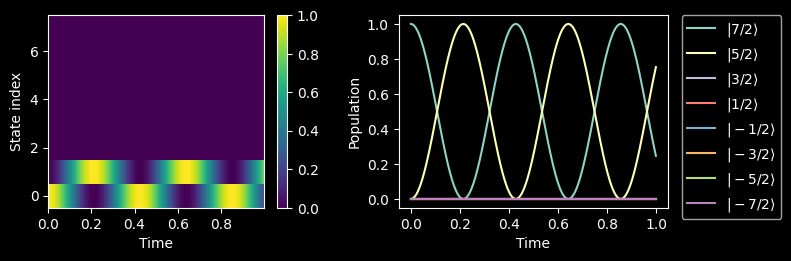

In [7]:
populations = trajectory.populations()

trajectory.plot_populations()

## Comparing Rabi frequencies across transitions

The Rabi frequency for the $|m\rangle \leftrightarrow |m-1\rangle$ transition is

$$\Omega_R^{(m)} = \frac{\gamma B_1}{2}\sqrt{I(I+1) - m(m-1)}$$

For $I = 7/2$ (taking $\gamma B_1 / 2 = 1$) this predicts:

| $i$ | Transition | $\Omega_R \,/\, (\gamma B_1 / 2)$ |
|:---:|:---|:---:|
| 0 | $\|{+7/2}\rangle \leftrightarrow \|{+5/2}\rangle$ | $\sqrt{7}  \approx 2.65$ |
| 1 | $\|{+5/2}\rangle \leftrightarrow \|{+3/2}\rangle$ | $\sqrt{12} \approx 3.46$ |
| 2 | $\|{+3/2}\rangle \leftrightarrow \|{+1/2}\rangle$ | $\sqrt{15} \approx 3.87$ |
| 3 | $\|{+1/2}\rangle \leftrightarrow \|{-1/2}\rangle$ | $4$ |
| 4 | $\|{-1/2}\rangle \leftrightarrow \|{-3/2}\rangle$ | $\sqrt{15} \approx 3.87$ |
| 5 | $\|{-3/2}\rangle \leftrightarrow \|{-5/2}\rangle$ | $\sqrt{12} \approx 3.46$ |
| 6 | $\|{-5/2}\rangle \leftrightarrow \|{-7/2}\rangle$ | $\sqrt{7}  \approx 2.65$ |

The central transition is the fastest; the outermost are the slowest; and the spectrum is symmetric about $m = 0$.
The loop below drives each transition independently and fits the oscillation to extract $\Omega_R$ numerically.

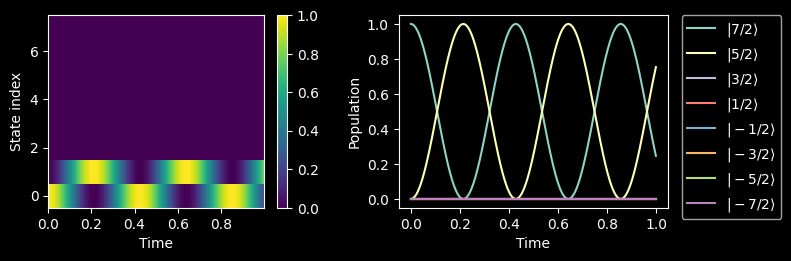

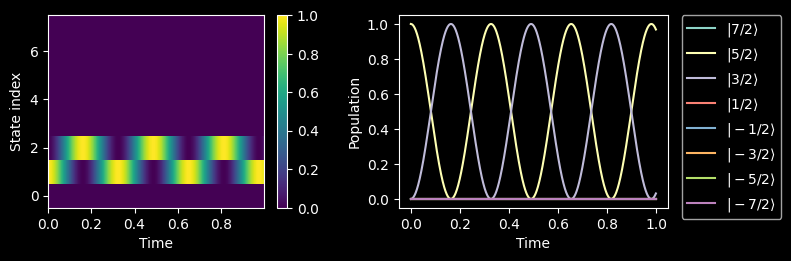

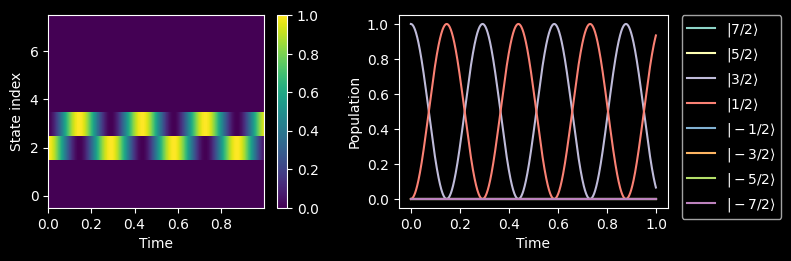

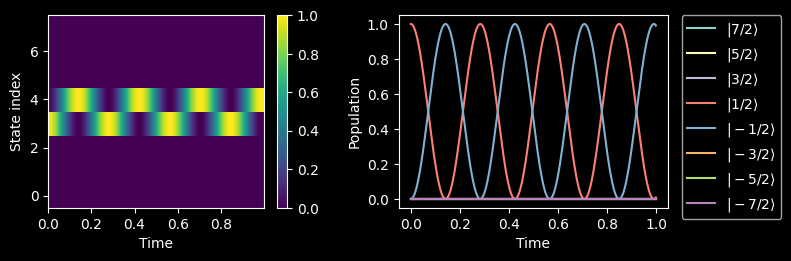

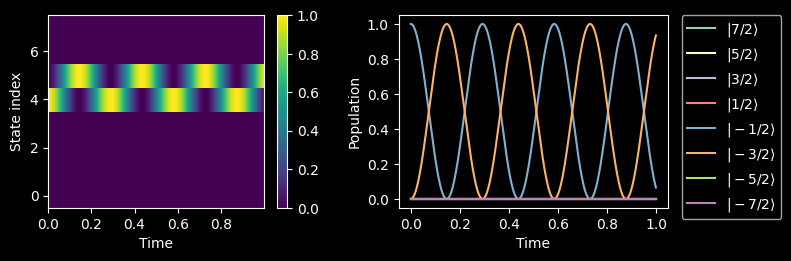

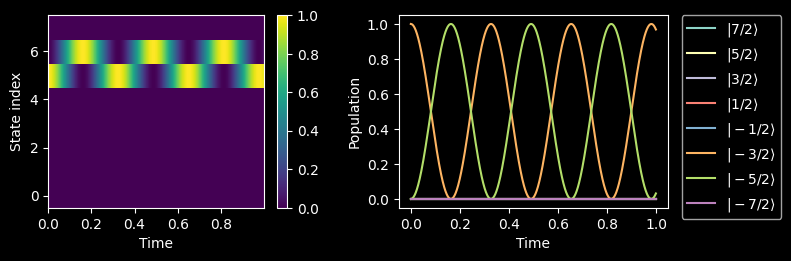

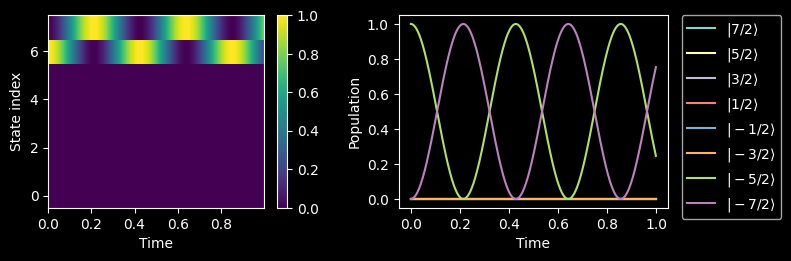

In [8]:
rabi_frequencies_nmr = np.zeros(7)

for i in range(0, 7):
    B1 = np.zeros(7)
    times = np.arange(0, 1, 0.001)
    nucleus.make_eigenstate(7/2-i) # initialize nuclear eigenstate
    B1[i] = 1 # activate one drive tone
    H_rf = nmr1_hamiltonian(7/2, B1, gamma=5.55) # MHz
    trajectory = nucleus.evolve(H_rf, times)
    populations = trajectory.populations()
    trajectory.plot_populations()
    rabi_fit = SineFit(populations[:, i], xvals=times)
    rabi_frequencies_nmr[i] = rabi_fit.fit_result.params['frequency']

Plotting the fitted frequencies reveals the characteristic **symmetric parabola** — a direct signature of the Clebsch-Gordan matrix elements for $I = 7/2$.

Text(0, 0.5, 'Rabi Frequency')

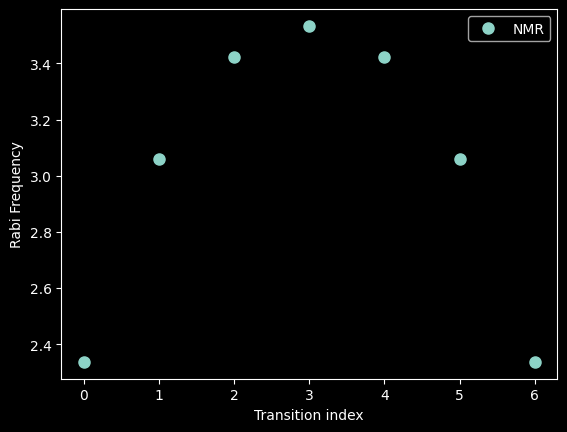

In [9]:
plt.plot(np.arange(0, 7), rabi_frequencies_nmr, 'o', markersize=8, label='NMR')
plt.legend()
plt.xlabel('Transition index')
plt.ylabel('Rabi Frequency')

## NER — Nuclear Electric Resonance

Electric field gradients couple to the nuclear **quadrupole moment** and can drive both
$\Delta m = 1$ and $\Delta m = 2$ transitions
(see: Asaad et al., *Nature* 2020, https://www.nature.com/articles/s41586-020-2057-7).

The quadrupole Hamiltonian $H_Q = \kappa \sum_{\alpha\beta} V_{\alpha\beta} I_\alpha I_\beta$
decomposes by the EFG tensor component that is oscillated:

| Oscillating EFG component | Rotating-frame operator | Transition |
|:---|:---|:---:|
| $V_{zz}$ | $3I_z^2 - \mathbf{I}^2$ | static splitting |
| $\delta V_{xz},\; \delta V_{yz}$ | $\{I_x, I_z\},\; \{I_y, I_z\}$ | $\Delta m = 1$ |
| $\delta V_{xx} - \delta V_{yy},\; \delta V_{xy}$ | $I_x^2 - I_y^2,\; \{I_x, I_y\}$ | $\Delta m = 2$ |

Applying an oscillating EFG at frequency $\omega$ produces a time-independent drive in the rotating frame
when $\omega$ is resonant with the target transition class.

### $\Delta m = 1$ — off-diagonal strain drive

An oscillating EFG at the Larmor frequency $\omega_L$ with non-zero $\delta V_{xz}$ or $\delta V_{yz}$ drives
$\Delta m = 1$ transitions via the anticommutators:

$$H_\text{NER1} = \kappa \bigl[\delta V_{xz}\,\{I_x, I_z\} + \delta V_{yz}\,\{I_y, I_z\}\bigr], \qquad \{A,B\} \equiv AB + BA$$

The matrix elements of $\{I_x, I_z\}$ between $|m\rangle$ and $|m-1\rangle$ carry an extra factor of $(2m-1)$
compared to the plain $I_x$ matrix elements used in NMR:

$$\langle m-1 | \{I_x, I_z\} | m \rangle = (2m-1)\,\langle m-1 | I_x | m \rangle
= \frac{2m-1}{2}\sqrt{I(I+1) - m(m-1)}$$

This factor **vanishes at the central transition** ($m = +1/2$, where $2m - 1 = 0$),
making NER1 the mirror image of NMR: fast at the edges, forbidden at the centre.

The `dQxz` and `dQyz` vectors control the two orthogonal drive channels independently:
`dQxz` rotates each subspace about $x$; `dQyz` rotates about $y$ (equivalent to a $90°$ phase shift).

We activate only the top transition ($|7/2\rangle \leftrightarrow |5/2\rangle$) via the $\{I_x, I_z\}$ channel (`dQxz[0] = 1`, all others zero). Inspecting $H_\text{NER1}$ confirms that only the $(0,1)$ and $(1,0)$ matrix elements are non-zero:

In [10]:
dQxz = [1, 0, 0, 0, 0, 0, 0] # say we only drive NER by modulating the Ix*Iz Hamiltonian term
dQyz = [0, 0, 0, 0, 0, 0, 0]
H_ner = ner1_hamiltonian(nucleus.I, dQxz, dQyz)
H_ner

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.         7.93725393 0.         0.         0.         0.
  0.         0.        ]
 [7.93725393 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

In [11]:
times = np.arange(0, 1, 0.001)
nucleus.make_eigenstate(7/2) # initialize nuclear eigenstate
trajectory = nucleus.evolve(H_ner, times)

(<Figure size 800x250 with 3 Axes>,
 array([<Axes: xlabel='Time', ylabel='State index'>,
        <Axes: xlabel='Time', ylabel='Population'>], dtype=object))

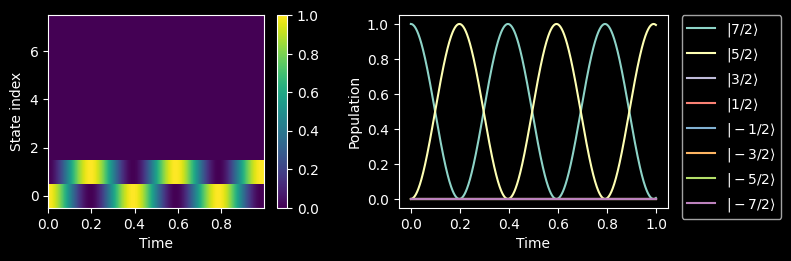

In [12]:
trajectory.plot_populations()

To illustrate that NER has the opposite behaviour in terms Rabi frequency compared to NMR, we display the NER Hamiltonian when all drive tones are activated.

In [13]:
## $\Delta m = 1$
dQxz = [1, 1, 1, 1, 1, 1, 1]  # say we only drive NER by modulating the Ix*Iz Hamiltonian term.
dQyz = [0, 0, 0, 0, 0, 0, 0] # if we would modulate the Iy*Iz terms instead we would change the axis of rotation.
H_ner = ner1_hamiltonian(nucleus.I, dQxz, dQyz)
H_ner

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.          7.93725393  0.          0.          0.          0.
   0.          0.        ]
 [ 7.93725393  0.          6.92820323  0.          0.          0.
   0.          0.        ]
 [ 0.          6.92820323  0.          3.87298335  0.          0.
   0.          0.        ]
 [ 0.          0.          3.87298335  0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.         -3.87298335
   0.          0.        ]
 [ 0.          0.          0.          0.         -3.87298335  0.
  -6.92820323  0.        ]
 [ 0.          0.          0.          0.          0.         -6.92820323
   0.         -7.93725393]
 [ 0.          0.          0.          0.          0.          0.
  -7.93725393  0.        ]]

The NER1 Rabi frequency pattern is the **inverse** of NMR — strongest at the edges, zero at the centre:

| $i$ | Transition | NMR $\Omega_R / (\gamma B_1/2)$ | NER1 $\Omega_R / \kappa$ |
|:---:|:---|:---:|:---:|
| 0 | $\|{+7/2}\rangle \leftrightarrow \|{+5/2}\rangle$ | $\sqrt{7}  \approx 2.65$ | $3\sqrt{7}  \approx 7.94$ |
| 1 | $\|{+5/2}\rangle \leftrightarrow \|{+3/2}\rangle$ | $\sqrt{12} \approx 3.46$ | $2\sqrt{12} \approx 6.93$ |
| 2 | $\|{+3/2}\rangle \leftrightarrow \|{+1/2}\rangle$ | $\sqrt{15} \approx 3.87$ | $\sqrt{15}  \approx 3.87$ |
| 3 | $\|{+1/2}\rangle \leftrightarrow \|{-1/2}\rangle$ | $4$ | $\mathbf{0}$ (forbidden) |
| 4 | $\|{-1/2}\rangle \leftrightarrow \|{-3/2}\rangle$ | $\sqrt{15} \approx 3.87$ | $\sqrt{15}  \approx 3.87$ |
| 5 | $\|{-3/2}\rangle \leftrightarrow \|{-5/2}\rangle$ | $\sqrt{12} \approx 3.46$ | $2\sqrt{12} \approx 6.93$ |
| 6 | $\|{-5/2}\rangle \leftrightarrow \|{-7/2}\rangle$ | $\sqrt{7}  \approx 2.65$ | $3\sqrt{7}  \approx 7.94$ |

The central transition ($i = 3$) is forbidden and is skipped in the fit loop below.

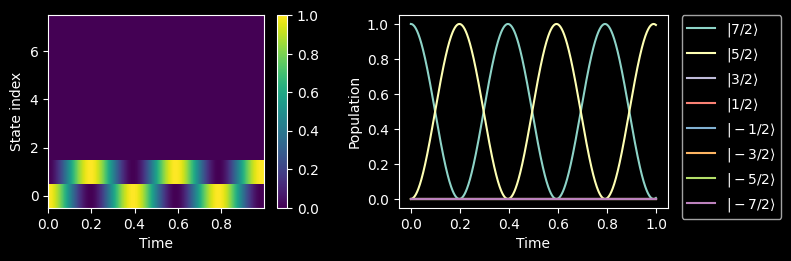

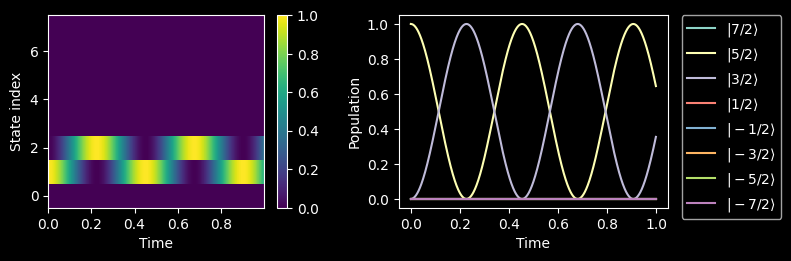

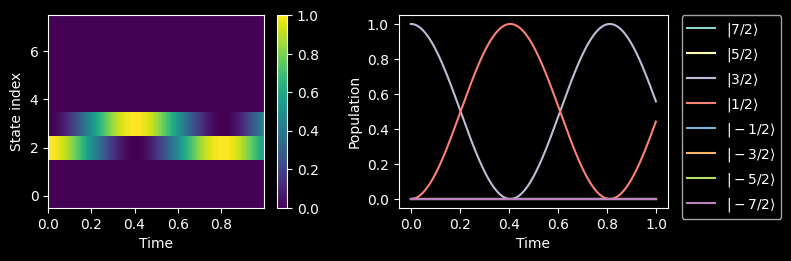

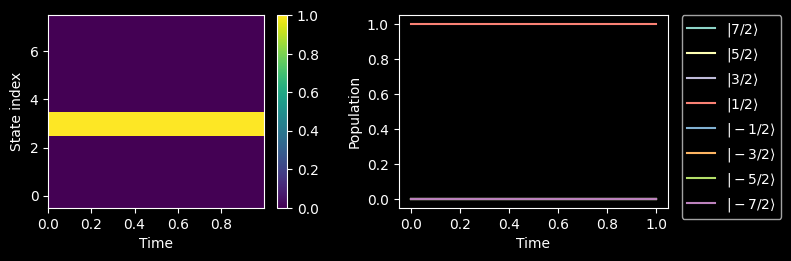

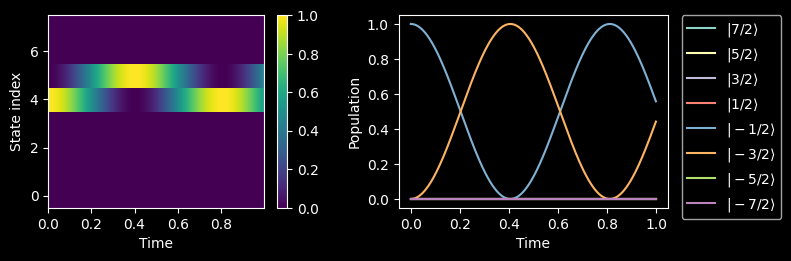

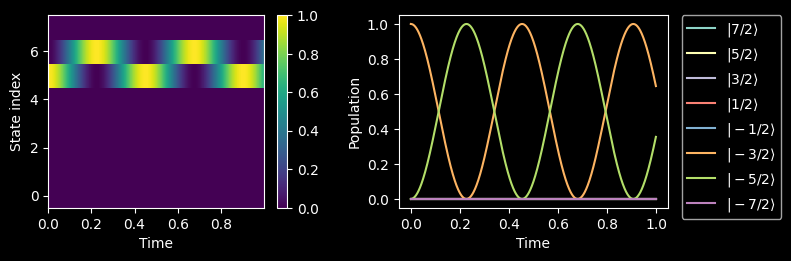

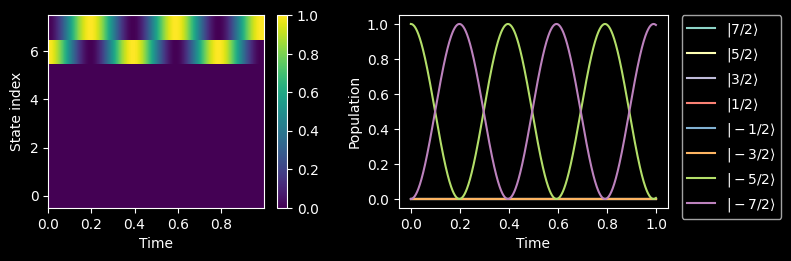

In [14]:
rabi_frequencies_ner1 = np.zeros(nucleus.dim - 1)
dQxz = np.zeros(nucleus.dim - 1)
dQyz = np.zeros(nucleus.dim - 1)

for i in range(0, nucleus.dim - 1):
    dQxz = np.zeros(nucleus.dim - 1)
    times = np.arange(0, 1, 0.001)
    nucleus.make_eigenstate(nucleus.I-i) # initialize nuclear eigenstate
    dQxz[i] = 1 # activate one drive tone
    H_ner = ner1_hamiltonian(nucleus.I, dQxz, dQyz) # MHz
    trajectory = nucleus.evolve(H_ner, times)
    populations = trajectory.populations()
    trajectory.plot_populations()
    if i != (nucleus.dim//2 - 1):
        rabi_fit = SineFit(populations[:, i], xvals=times)
        rabi_frequencies_ner1[i] = rabi_fit.fit_result.params['frequency']

Text(0, 0.5, 'Rabi Frequency')

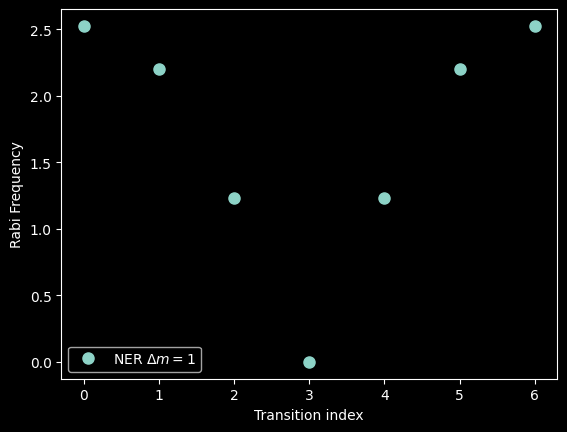

In [15]:
plt.plot(np.arange(0, 7), rabi_frequencies_ner1, 'o', markersize=8, label=r'NER $\Delta m = 1$')
plt.legend()
plt.xlabel('Transition index')
plt.ylabel('Rabi Frequency')

### $\Delta m = 2$ — quadrupole transverse drive

An oscillating EFG at **twice** the Larmor frequency $2\omega_L$ drives $\Delta m = 2$ transitions via:

$$H_\text{NER2} = \kappa \left[\frac{\delta V_{xx} - \delta V_{yy}}{2}\,(I_x^2 - I_y^2)
                               + \delta V_{xy}\,\{I_x, I_y\}\right]$$

In terms of raising/lowering operators: $I_x^2 - I_y^2 = \tfrac{1}{2}(I_+^2 + I_-^2)$
and $\{I_x, I_y\} = \tfrac{1}{2i}(I_+^2 - I_-^2)$.
The matrix elements are:

$$\langle m-2 | I_\pm^2 | m \rangle = \sqrt{I(I+1) - m(m\mp 1)}\;\sqrt{I(I+1) - (m\mp 1)(m\mp 2)}$$

Unlike NER1, a uniaxial crystal ($\eta = 0$) *can* support NER2 provided an oscillating $\delta V_{xx} - \delta V_{yy}$
or $\delta V_{xy}$ component is present. NER2 was used in the original Asaad et al. (2020) experiment to
demonstrate single-qudit control of the $^{123}$Sb nucleus.

In [16]:
dQxx_yy = [1, 0, 0, 0, 0, 0] # say we only drive NER by modulating the Ix*Iz Hamiltonian term
dQxy = [0, 0, 0, 0, 0, 0]
H_ner2 = ner2_hamiltonian(nucleus.I, dQxx_yy, dQyz)
H_ner2

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.         0.         4.58257569 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [4.58257569 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

In [17]:
times = np.arange(0, 1, 0.001)
nucleus.make_eigenstate(7/2) # initialize nuclear eigenstate
trajectory = nucleus.evolve(H_ner2, times)

(<Figure size 800x250 with 3 Axes>,
 array([<Axes: xlabel='Time', ylabel='State index'>,
        <Axes: xlabel='Time', ylabel='Population'>], dtype=object))

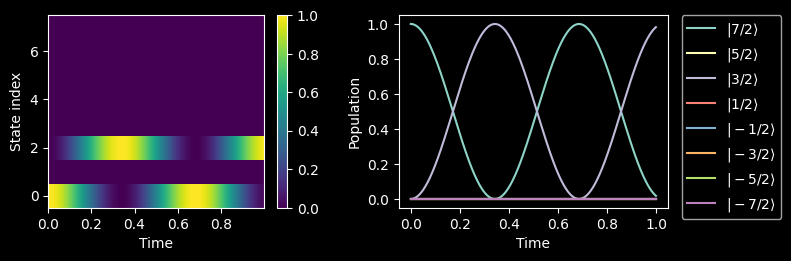

In [18]:
trajectory.plot_populations()

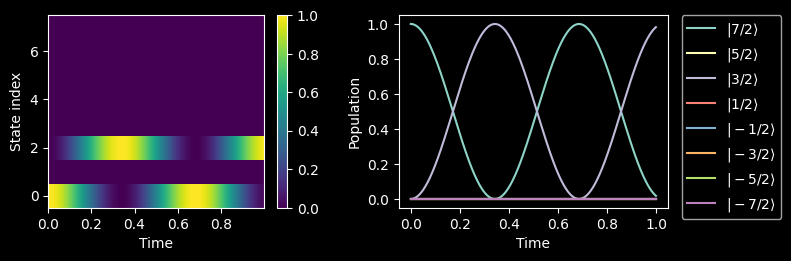

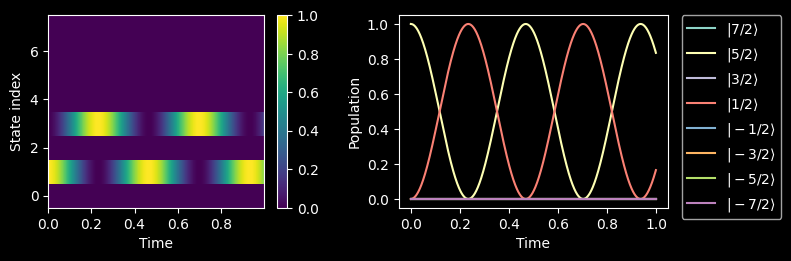

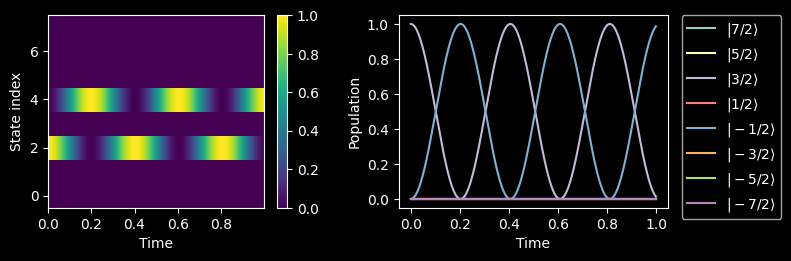

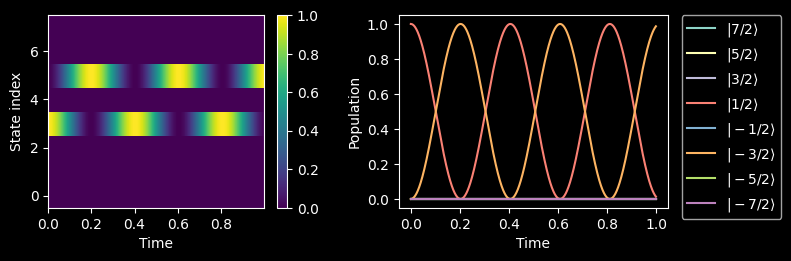

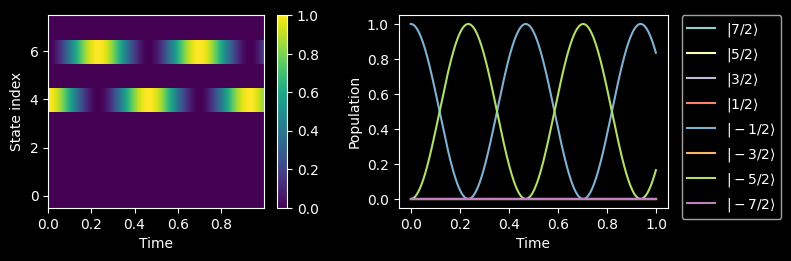

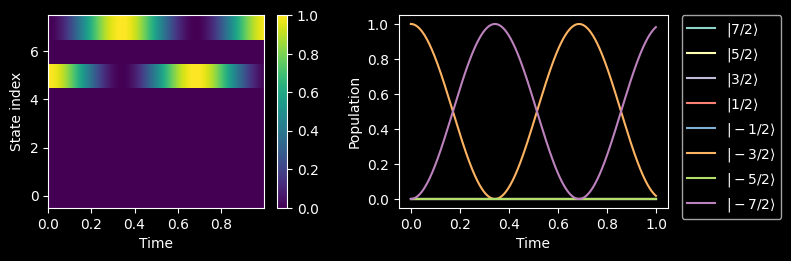

In [19]:
rabi_frequencies_ner2 = np.zeros(nucleus.dim - 2)
dQxx_yy = np.zeros(nucleus.dim - 2)
dQxy = np.zeros(nucleus.dim - 2)

for i in range(0, nucleus.dim - 2):
    dQxx_yy = np.zeros(nucleus.dim - 2)
    times = np.arange(0, 1, 0.001)
    nucleus.make_eigenstate(nucleus.I-i) # initialize nuclear eigenstate
    dQxx_yy[i] = 1 # activate one drive tone
    H_ner = ner2_hamiltonian(nucleus.I, dQxx_yy, dQxy) # MHz
    trajectory = nucleus.evolve(H_ner, times)
    populations = trajectory.populations()
    trajectory.plot_populations()
    rabi_fit = SineFit(populations[:, i], xvals=times)
    rabi_frequencies_ner2[i] = rabi_fit.fit_result.params['frequency']

Text(0, 0.5, 'Rabi Frequency')

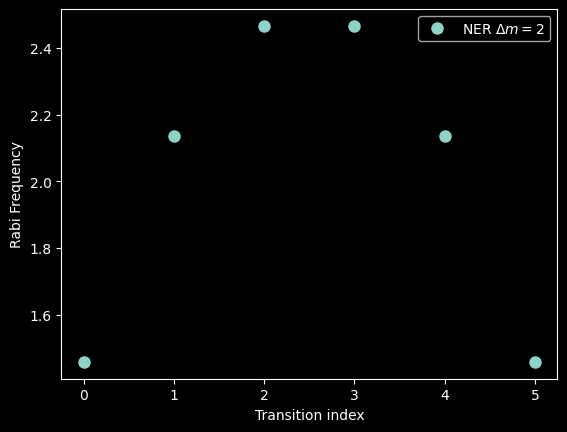

In [20]:
plt.plot(np.arange(0, 6), rabi_frequencies_ner2, 'o', markersize=8, label=r'NER $\Delta m = 2$')
plt.legend()
plt.xlabel('Transition index')
plt.ylabel('Rabi Frequency')

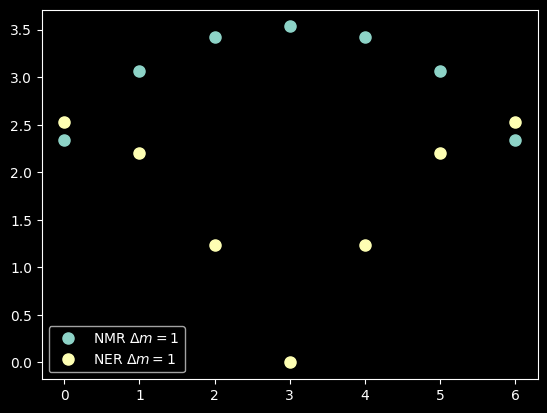

In [21]:
plt.plot(np.arange(0, 7), rabi_frequencies_nmr, 'o', markersize=8, label=r'NMR $\Delta m = 1$')
plt.plot(np.arange(0, 7), rabi_frequencies_ner1, 'o', markersize=8, label=r'NER $\Delta m = 1$')
# plt.plot(np.arange(0, 6), rabi_frequencies_ner2, 'o', markersize=8, label=r'NER $\Delta m = 2$')
plt.legend()